## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [4]:
timeline_file.head()

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213
1,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432
2,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009
3,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316
4,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469


In [5]:
wnv_file.head()

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0


In [6]:
#timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [8]:
timeline_file = convert_temperature(timeline_file)

In [9]:
timeline_file

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,2.030213,5.530000,5.530000,NaN,NaN,NaN
1,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,1.997432,5.530000,5.530000,NaN,NaN,NaN
2,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,0.882009,5.530000,5.530000,NaN,NaN,NaN
3,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,1.242316,5.530000,5.530000,NaN,NaN,NaN
4,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,0.093469,5.530000,5.530000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-27,27,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,6.790000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,9.220000,5.021290,6.575357,5.824194,5.824194
3067204,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.650000,6.790000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,9.220000,5.021290,6.575357,5.824194,5.824194
3067205,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-29,29,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,5.130000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,8.390000,5.021290,6.575357,5.824194,5.824194
3067206,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-30,30,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,5.310000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,8.480000,5.021290,6.575357,5.824194,5.824194


In [10]:
dataset = pd.DataFrame()
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

In [11]:
grouped = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.571481,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156,0.010527,0.018527,1077.473491
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678,0.428337,0.651870,1158.041206
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785,1.072827,3.092039,1224.182744
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31.000000,12.000000,2022.000000,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,11.153506,3.022727,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.088117,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358


In [12]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset.head(5)

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.571481,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789


In [15]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.215876,40.552658,2010-01-01,57
1,23.139532,40.695359,2010-01-01,123
2,22.758634,41.016242,2010-01-01,96
3,22.109199,40.888821,2010-01-01,29
4,22.441443,40.269748,2010-01-01,87
...,...,...,...,...
33231,22.758634,41.016242,2022-12-31,4
33232,22.109199,40.888821,2022-12-31,6
33233,22.441443,40.269748,2022-12-31,9
33234,23.542098,41.085750,2022-12-31,3


In [16]:
df_mosquitoes['dt_placement'] = pd.to_datetime(df_mosquitoes['dt_placement'])

In [17]:
dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

df_mosquitoes['x.approx'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y.approx'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [18]:
dataset = pd.merge(dataset, df_mosquitoes,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

<AxesSubplot:>

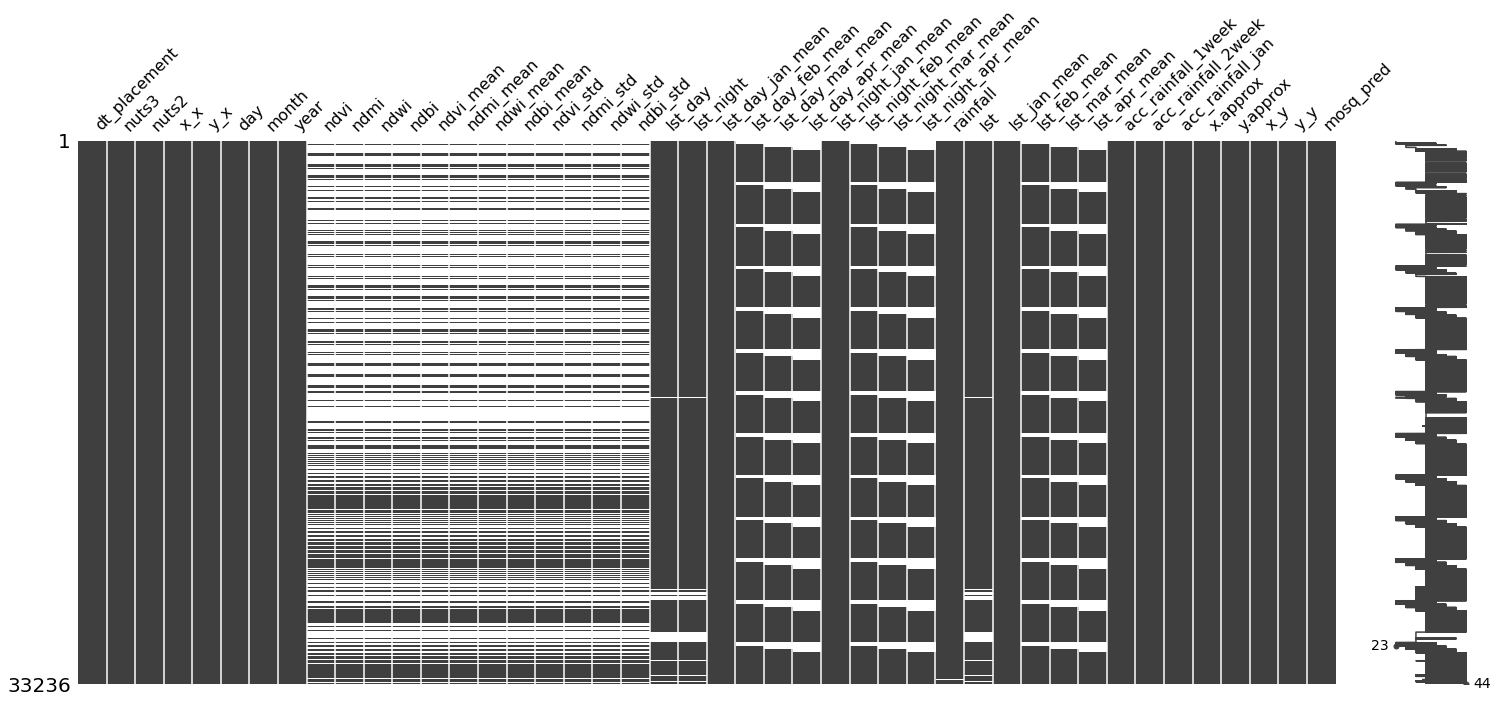

In [19]:
missingno.matrix(dataset)

In [20]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)


In [21]:
dataset.distance.max()

7.062385047625849e-10

In [22]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [23]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.571481,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681,57
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066,123
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223,96
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,29
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156,0.010527,0.018527,1077.473491,4
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31,12,2022,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678,0.428337,0.651870,1158.041206,6
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31,12,2022,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785,1.072827,3.092039,1224.182744,9
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31,12,2022,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,11.153506,3.022727,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.088117,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358,3


In [24]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [25]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [26]:
dataset

,dt_placement_daily,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,dt_placement
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.571481,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681,57,2010-01
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066,123,2010-01
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223,96,2010-01
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,29,2010-01
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789,87,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156,0.010527,0.018527,1077.473491,4,2022-12
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31,12,2022,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678,0.428337,0.651870,1158.041206,6,2022-12
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31,12,2022,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785,1.072827,3.092039,1224.182744,9,2022-12
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31,12,2022,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,11.153506,3.022727,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.088117,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358,3,2022-12


In [27]:
grouped = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset_month = grouped.mean()
dataset_month

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,51.741935
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,82.387097
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,55.129032
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,41.000000
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,61.129032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,6.870968
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,10.806452
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.454793,8.549293,4.673812,7.566929,6.941785,6.941785,3.536812,7.632461,1219.078173,11.967742
1090,2022-12,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,16.000000,12.000000,2022.000000,0.258193,-0.037033,-0.251383,0.037033,0.246811,-0.019297,-0.236606,0.019297,0.045739,0.043301,0.038884,0.043301,10.229044,4.186004,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.362598,7.207524,3.224755,7.213650,7.518062,7.518062,2.811723,6.023941,1085.465943,5.516129


In [28]:
wnv_file.head(5)

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0


In [30]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        1092 non-null   period[M]
 1   nuts3               1092 non-null   object   
 2   nuts2               1092 non-null   object   
 3   x                   1092 non-null   float64  
 4   y                   1092 non-null   float64  
 5   day                 1092 non-null   float64  
 6   month               1092 non-null   float64  
 7   year                1092 non-null   float64  
 8   ndvi                1035 non-null   float64  
 9   ndmi                1035 non-null   float64  
 10  ndwi                1035 non-null   float64  
 11  ndbi                1035 non-null   float64  
 12  ndvi_mean           1036 non-null   float64  
 13  ndmi_mean           1036 non-null   float64  
 14  ndwi_mean           1036 non-null   float64  
 15  ndbi_mean           1

In [34]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   nuts2         378 non-null    object   
 1   nuts3         378 non-null    object   
 2   dt_placement  378 non-null    period[M]
 3   cases         378 non-null    int64    
dtypes: int64(1), object(2), period[M](1)
memory usage: 11.9+ KB


In [33]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [35]:
wnv_file

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0
...,...,...,...,...
373,κεντρικης μακεδονιας,χαλκιδικης,2022-07,0
374,κεντρικης μακεδονιας,χαλκιδικης,2022-08,12
375,κεντρικης μακεδονιας,χαλκιδικης,2022-09,10
376,κεντρικης μακεδονιας,χαλκιδικης,2022-10,1


In [39]:
wnv_file['cases'].value_counts()

0     240
1      39
2      22
3      17
4      10
5       8
11      5
6       5
10      5
7       5
12      4
13      3
8       2
17      2
20      2
16      1
9       1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [40]:
wnv_file.cases.sum()

863

In [36]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'nuts3', 'nuts2'] )

In [37]:
merged

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,cases
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,51.741935,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,82.387097,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,55.129032,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,41.000000,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,61.129032,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,6.870968,NaN
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,10.806452,NaN
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.454793,8.549293,4.673812,7.566929,6.941785,6.941785,3.536812,7.632461,1219.078173,11.967742,NaN
1090,2022-12,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,16.000000,12.000000,2022.000000,0.258193,-0.037033,-0.251383,0.037033,0.246811,-0.019297,-0.236606,0.019297,0.045739,0.043301,0.038884,0.043301,10.229044,4.186004,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.362598,7.207524,3.224755,7.213650,7.518062,7.518062,2.811723,6.023941,1085.465943,5.516129,NaN


In [42]:
merged = fillna(merged,{'cases': 0})

In [38]:
merged['cases'].value_counts()

0.000000     240
1.000000      39
2.000000      22
3.000000      17
4.000000      10
5.000000       8
10.000000      5
11.000000      5
7.000000       5
6.000000       5
12.000000      4
13.000000      3
17.000000      2
8.000000       2
20.000000      2
50.000000      1
9.000000       1
16.000000      1
41.000000      1
34.000000      1
27.000000      1
40.000000      1
49.000000      1
36.000000      1
Name: cases, dtype: int64

In [41]:
merged.cases.sum()

863.0

In [43]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [47]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

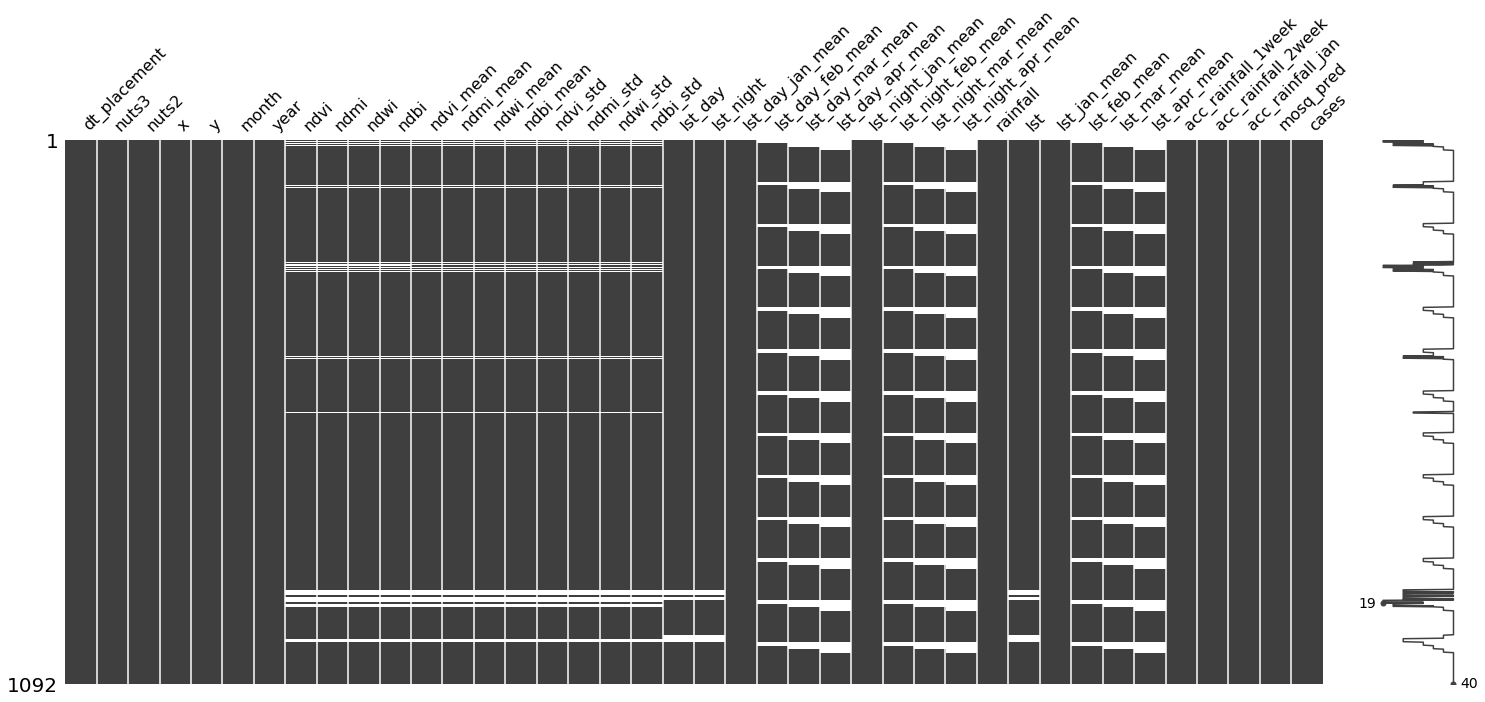

In [48]:
missingno.matrix(merged)

In [49]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [50]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [51]:
# df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()
df_demographics_nuts2 = df_demographics.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [52]:
code_to_name = {
    'EL521': 'ημαθιας',
    'EL522': 'θεσσαλονικης',
    'EL523': 'κιλκις',
    'EL524': 'πελλας',
    'EL525': 'πιεριας',
    'EL526': 'σερρων',
    'EL527': 'χαλκιδικης'
}

df_demographics_nuts2['NUTS3_NAME'] = df_demographics_nuts2['NUTS3_CODE'].map(code_to_name)

In [53]:
# df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)
df_demographics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [54]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,14806.000000,46909.000000,6931.000000,68646.000000,14017.000000,47825.000000,8438.000000,70280.000000,ημαθιας
1,1992,14246.000000,47131.000000,7225.000000,68602.000000,13469.000000,47787.000000,8705.000000,69961.000000,ημαθιας
2,1993,13788.000000,47587.000000,7494.000000,68869.000000,13007.000000,48018.000000,9004.000000,70029.000000,ημαθιας
3,1994,13299.000000,47838.000000,7841.000000,68978.000000,12575.000000,48064.000000,9368.000000,70007.000000,ημαθιας
4,1995,12800.000000,47871.000000,8178.000000,68849.000000,12130.000000,48007.000000,9686.000000,69823.000000,ημαθιας
...,...,...,...,...,...,...,...,...,...,...
219,2018,8221.000000,34856.000000,12433.000000,55510.000000,7846.000000,33852.000000,13379.000000,55077.000000,χαλκιδικης
220,2019,8027.000000,34838.000000,12589.000000,55454.000000,7727.000000,33834.000000,13578.000000,55139.000000,χαλκιδικης
221,2020,7900.000000,34760.000000,12776.000000,55436.000000,7554.000000,33835.000000,13764.000000,55153.000000,χαλκιδικης
222,2021,7725.000000,34568.000000,12921.000000,55214.000000,7408.000000,33800.000000,13851.000000,55059.000000,χαλκιδικης


In [55]:
names_from_merged = merged["nuts3"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [37]:
# df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [38]:
# names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
# names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_merged:
#     if element not in names_from_demographics:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [56]:
dataset = pd.merge(merged, df_demographics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

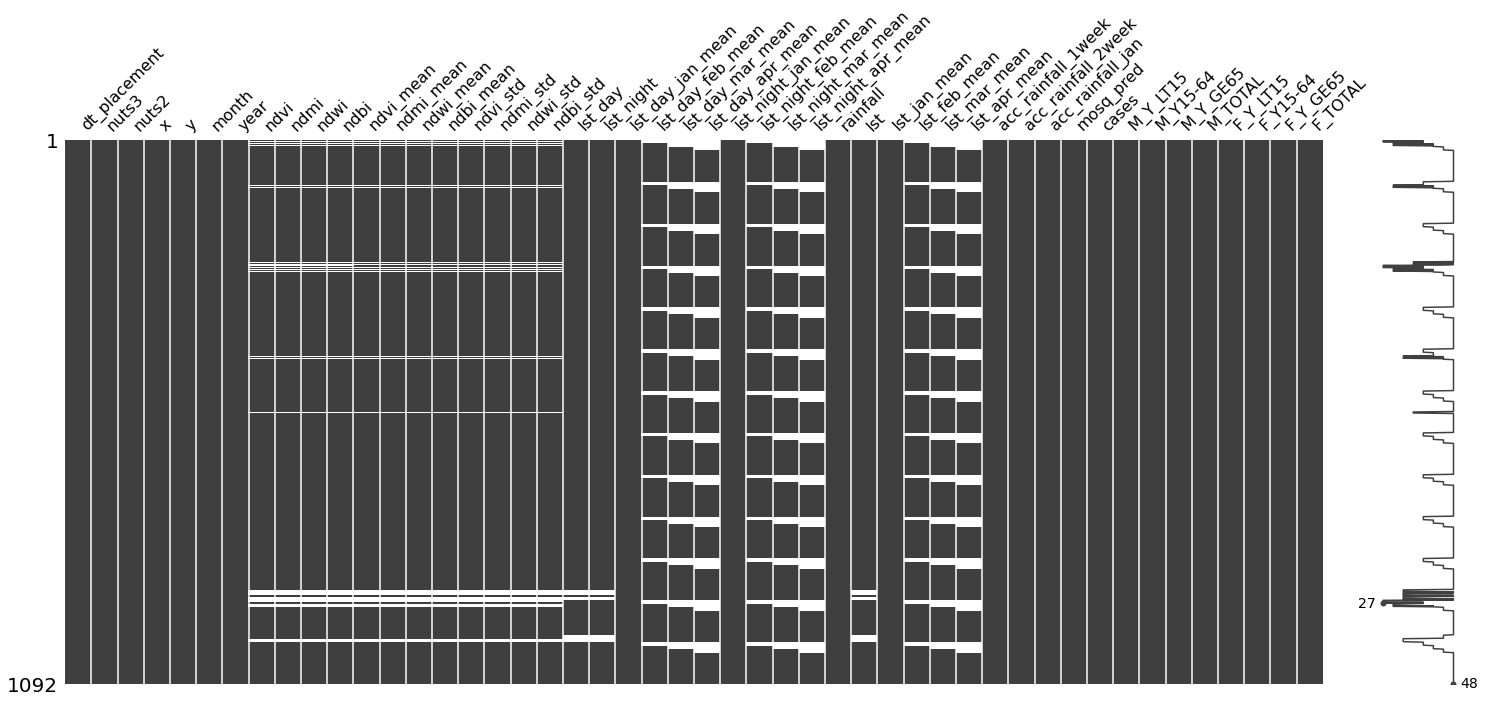

In [57]:
missingno.matrix(dataset)

In [58]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [59]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [60]:
df_economics_nuts2 = df_economics.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [61]:
df_economics_nuts2['NUTS3_NAME'] = df_economics_nuts2['NUTS3_CODE'].map(code_to_name)
df_economics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_economics_nuts2.reset_index(inplace=True, drop=True)
df_economics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [62]:
df_economics_nuts2

,year,MIO_EUR,nuts3
0,2000,1467.800000,ημαθιας
1,2001,1576.300000,ημαθιας
2,2002,1614.200000,ημαθιας
3,2003,1690.930000,ημαθιας
4,2004,1806.780000,ημαθιας
...,...,...,...
142,2016,1457.490000,χαλκιδικης
143,2017,1470.520000,χαλκιδικης
144,2018,1521.240000,χαλκιδικης
145,2019,1529.360000,χαλκιδικης


In [63]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [64]:
dataset = pd.merge(dataset, df_economics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

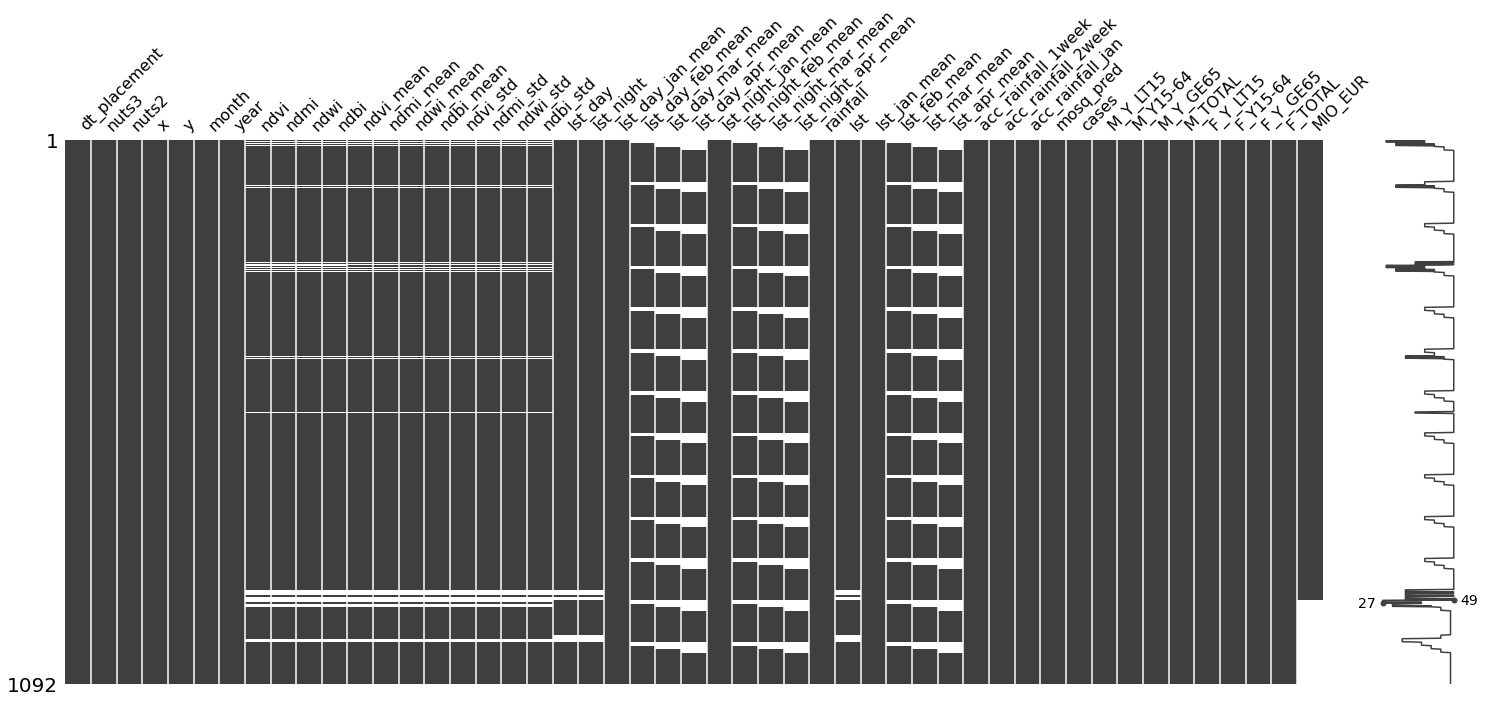

In [65]:
missingno.matrix(dataset)

In [66]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [67]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [68]:
df_trade_nuts2 = df_trade.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [69]:
df_trade_nuts2['NUTS3_NAME'] = df_trade_nuts2['NUTS3_CODE'].map(code_to_name)
df_trade_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_trade_nuts2.reset_index(inplace=True, drop=True)
df_trade_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [70]:
df_trade_nuts2

,year,L_TOTAL,UNL_TOTAL,nuts3
0,2015,4287.000000,4163.000000,ημαθιας
1,2016,3098.000000,4223.000000,ημαθιας
2,2017,1714.000000,2015.000000,ημαθιας
3,2018,1790.000000,1892.000000,ημαθιας
4,2019,1884.000000,2164.000000,ημαθιας
5,2020,1662.000000,1901.000000,ημαθιας
6,2021,1706.000000,2112.000000,ημαθιας
7,2015,13373.000000,15210.000000,θεσσαλονικης
8,2016,25046.000000,26693.000000,θεσσαλονικης
9,2017,21952.000000,20502.000000,θεσσαλονικης


In [71]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_trade_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [72]:
dataset = pd.merge(dataset, df_trade_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

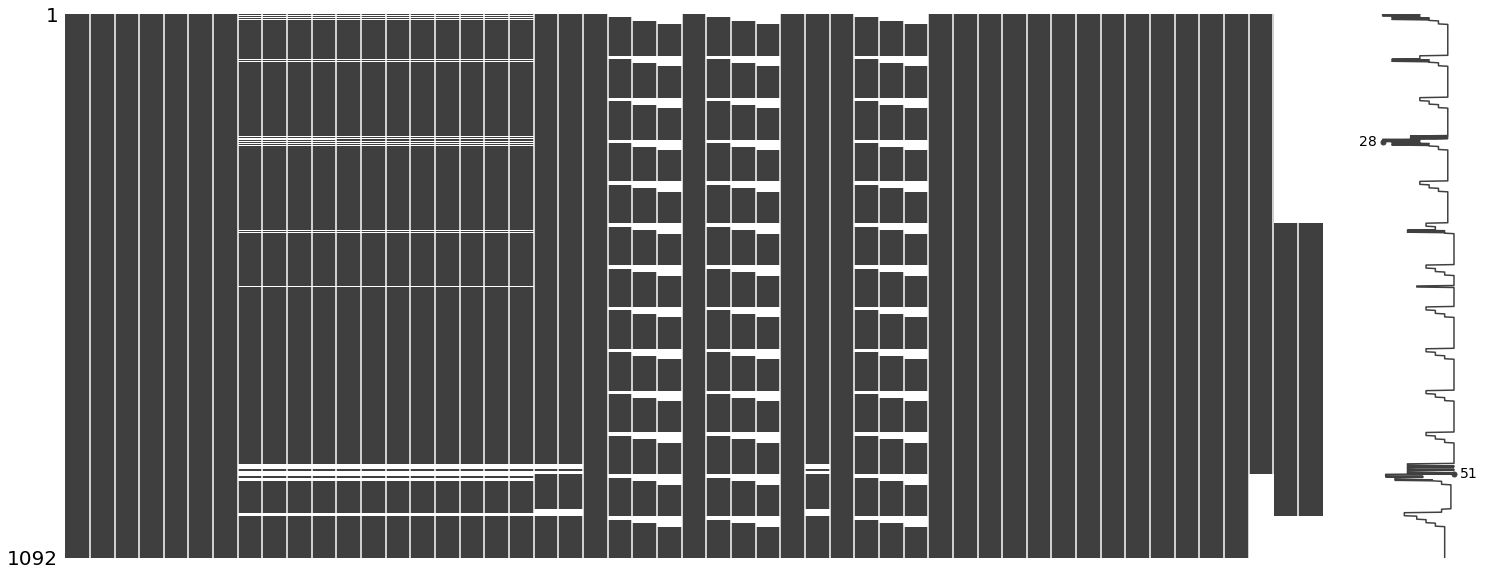

In [73]:
missingno.matrix(dataset)

In [74]:
missing = describe_dataframe(dataset)

In [75]:
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,5.219780
8,ndmi,5.219780
9,ndwi,5.219780


In [76]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,cases,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,51.741935,0,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,82.387097,0,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,55.129032,0,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,41.000000,0,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,61.129032,0,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,12,2022,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,6.870968,0,4675.000000,21563.000000,8269.000000,34507.000000,4572.000000,20435.000000,10709.000000,35716.000000,NaN,NaN,NaN
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,12,2022,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,10.806452,0,8752.000000,39332.000000,14000.000000,62084.000000,8343.000000,38438.000000,17398.000000,64179.000000,NaN,NaN,NaN
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,12,2022,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.19

In [77]:
dataset.reset_index(inplace=True, drop=True)

In [78]:
dataset['cases'].value_counts()

0     954
1      39
2      22
3      17
4      10
5       8
10      5
11      5
7       5
6       5
12      4
13      3
17      2
8       2
20      2
50      1
9       1
16      1
41      1
34      1
27      1
40      1
49      1
36      1
Name: cases, dtype: int64

In [79]:
dataset['cases'].sum()

863

In [81]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,cases,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,51.741935,0,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,82.387097,0,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,55.129032,0,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,41.000000,0,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,61.129032,0,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,12,2022,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,6.870968,0,4675.000000,21563.000000,8269.000000,34507.000000,4572.000000,20435.000000,10709.000000,35716.000000,NaN,NaN,NaN
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,12,2022,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,10.806452,0,8752.000000,39332.000000,14000.000000,62084.000000,8343.000000,38438.000000,17398.000000,64179.000000,NaN,NaN,NaN
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,12,2022,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.19

In [82]:
cols = dataset.columns

In [83]:
cols

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'month', 'year', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean',
       'lst_day_apr_mean', 'lst_night_jan_mean', 'lst_night_feb_mean',
       'lst_night_mar_mean', 'lst_night_apr_mean', 'rainfall', 'lst',
       'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'cases', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
       'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL',
       'UNL_TOTAL'],
      dtype='object')

In [84]:
len(cols)

51

In [60]:
# check columns

In [87]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'nuts2', 'nuts3',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 
                 'lst', 'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean', 'lst_day_apr_mean', 
                 'lst_night_jan_mean', 'lst_night_feb_mean', 'lst_night_mar_mean', 'lst_night_apr_mean', 
                 'rainfall', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [88]:
len(final_columns)

51

In [89]:
dataset_final = dataset[final_columns].copy()

In [90]:
dataset_final

,x,y,month,year,dt_placement,nuts2,nuts3,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,22.215876,40.552658,1,2010,2010-01,κεντρικης μακεδονιας,ημαθιας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.443226,6.168909,2.702302,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,15.306163,25.795942,35.973005,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN,51.741935,0
1,23.139532,40.695359,1,2010,2010-01,κεντρικης μακεδονιας,θεσσαλονικης,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,4.816764,7.923406,1.710122,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,7.807795,13.338001,19.783772,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN,82.387097,0
2,22.758634,41.016242,1,2010,2010-01,κεντρικης μακεδονιας,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,3.765541,7.190461,0.340620,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,9.279576,14.213017,18.993597,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN,55.129032,0
3,22.109199,40.888821,1,2010,2010-01,κεντρικης μακεδονιας,πελλας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.694941,6.414831,0.975051,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,14.713423,22.905129,32.657020,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN,41.000000,0
4,22.441443,40.269748,1,2010,2010-01,κεντρικης μακεδονιας,πιεριας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.091283,8.354315,3.828251,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,15.859868,27.160592,39.731443,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN,61.129032,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,22.758634,41.016242,12,2022,2022-12,κεντρικης μακεδονιας,κιλκις,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,7.386613,11.139610,3.633616,3.849625,7.509843,7.500156,7.500156,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,3.368094,7.215676,1073.761431,4675.000000,21563.000000,8269.000000,34507.000000,4572.000000,20435.000000,10709.000000,35716.000000,NaN,NaN,NaN,6.870968,0
1088,22.109199,40.888821,12,2022,2022-12,κεντρικης μακεδονιας,πελλας,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,7.168931,11.136942,3.200919,3.735237,6.977415,6.480678,6.480678,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,1.949946,4.340783,1155.499660,8752.000000,39332.000000,14000.000000,62084.000000,8343.000000,38438.000000,17398.000000,64179.000000,NaN,NaN,NaN,10.806452,0
1089,22.441443,40.269748,12,2022,2022-12,κεντρικης μακεδονιας,πιεριας,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,8.549293,11.967030,5.131556,4.673812,7.566929,6.941785,6.941785,8.892165,12.9372

<AxesSubplot:>

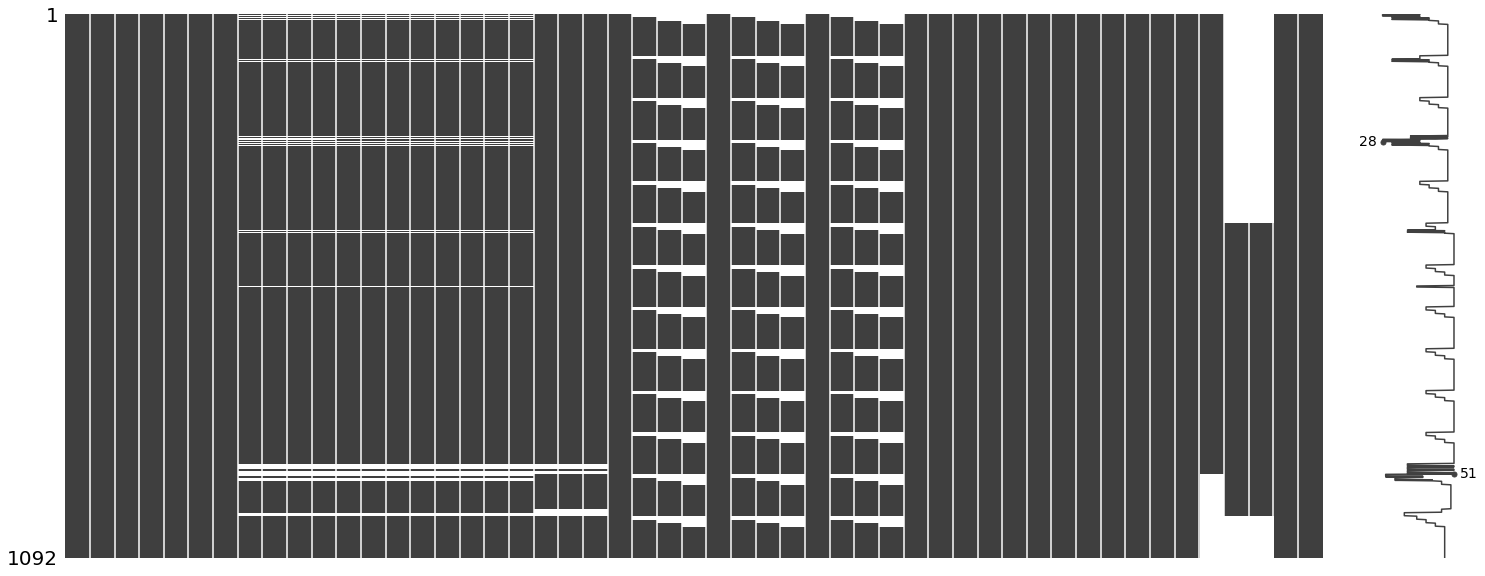

In [92]:
missingno.matrix(dataset_final)

In [93]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)